# Exploratory Data Analysis
## On Parsed Data

This notebook analyzes the records produced by `02_document_parsing.ipynb` to evaluate their fitness for the RAG system.

**Objectives:**
1. **Variable Description**: Outline the fields and their representation.
2. **Data Quality & Hygiene**: Identify noise and determine cleaning requirements.
3. **Utility for Goal**: Evaluate how well the dataset supports grounded, citable retrieval.
4. **Variable Interactions**: Analyze relationships between `element_type`, `text_length`, and `chapter`.

In [14]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Constants
JSONL_PATH = Path("../data/processed/san_diego_code_structured.jsonl")

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Load Data
df = pd.read_json(JSONL_PATH, lines=True)
df["text_length"] = df["text"].str.len()

print(f"Loaded {len(df):,} records | Columns: {list(df.columns)}")
df.head(3)

Loaded 64,639 records | Columns: ['chapter', 'filename', 'element_type', 'text', 'text_length']


,chapter,filename,element_type,text,text_length
0,chapter_11,Ch11Art03Division02.pdf,Header,San Diego Municipal Code (10-2024),34
1,chapter_11,Ch11Art03Division02.pdf,Header,Chapter 11: Land Development Procedures,39
2,chapter_11,Ch11Art03Division02.pdf,Title,Article 3: Land Development Procedures,38


## 1. Data Profiling

Description of each field in the dataset:

| Field | Plain-Language Name | Description |
|---|---|---|
| `chapter` | Context | The major legal chapter (11-15) the text belongs to. |
| `filename` | Source | The specific PDF file the text was extracted from. |
| `element_type` | Structural Role | Whether the text is a heading (`Title`), legal paragraph (`NarrativeText`), text fragment (`Text`), list item (`ListItem`), or page furniture (`Header`/`Footer`). |
| `text` | Content | The actual extracted words, discovered symbols, and regulations. |


Record Counts by Chapter:
chapter
chapter_11     2535
chapter_12     5952
chapter_13    21701
chapter_14    21060
chapter_15    13391


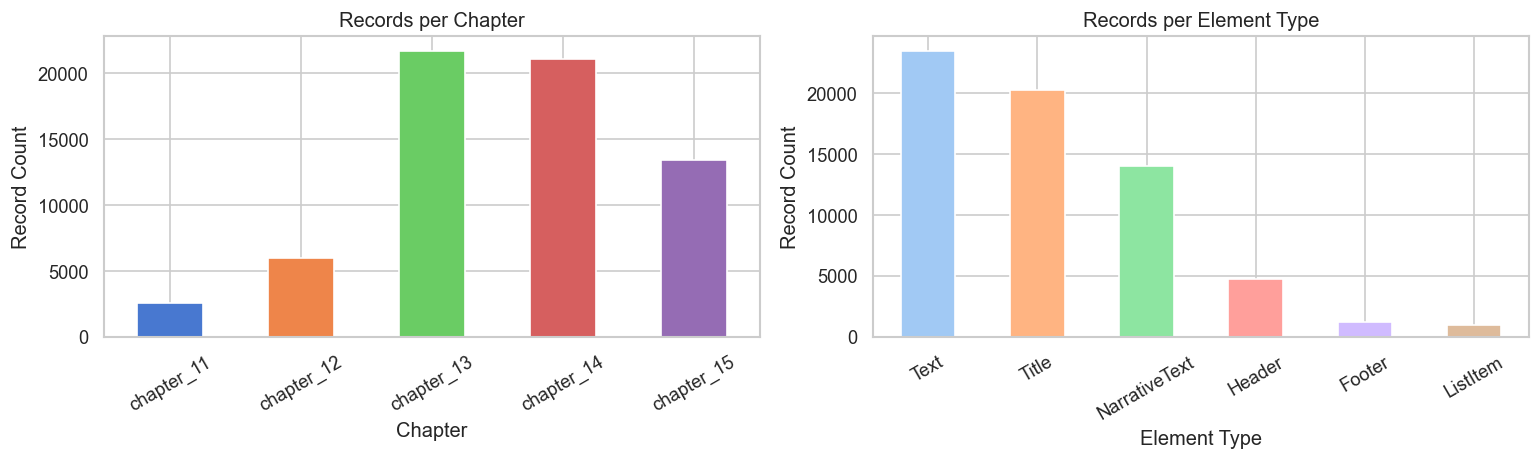


Unique source files: 245


In [15]:
# 1a. Record counts by chapter and element type
print("Record Counts by Chapter:")
chapter_counts = df["chapter"].value_counts().sort_index()
print(chapter_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

chapter_counts.plot(kind="bar", ax=axes[0], color=sns.color_palette("muted", len(chapter_counts)))
axes[0].set_title("Records per Chapter")
axes[0].set_xlabel("Chapter")
axes[0].set_ylabel("Record Count")
axes[0].tick_params(axis="x", rotation=30)

element_counts = df["element_type"].value_counts()
element_counts.plot(kind="bar", ax=axes[1], color=sns.color_palette("pastel", len(element_counts)))
axes[1].set_title("Records per Element Type")
axes[1].set_xlabel("Element Type")
axes[1].set_ylabel("Record Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"\nUnique source files: {df['filename'].nunique()}")

## 2. Data Quality & Hygiene
Quantification of quality issues to address prior to vector store ingestion.

In [16]:
# 2a. Noise elements (Headers & Footers)
noise_types = ["Header", "Footer"]
noise_df = df[df["element_type"].isin(noise_types)]
noise_pct = len(noise_df) / len(df) * 100

print("Noise Elements (Headers & Footers):")
print(f"Noise records: {len(noise_df):,} ({noise_pct:.1f}% of total)")
print("\nMost frequent Header/Footer strings:")
print(noise_df["text"].value_counts().head(10).to_string())

Noise Elements (Headers & Footers):
Noise records: 5,933 (9.2% of total)

Most frequent Header/Footer strings:
text
Chapter 14: General Regulations            928
San Diego Municipal Code (2-2025)          921
Chapter 15: Planned Districts              522
Chapter 13: Zones                          452
San Diego Municipal Code (10-2024)         353
Chapter 12: Land Development Reviews       352
San Diego Municipal Code (8-2025)          144
San Diego Municipal Code (4-2024)          141
14                                         137
Chapter 11: Land Development Procedures    136


In [17]:
# 2b. Missing / Empty Text
empty_mask = df["text"].str.strip().eq("") | df["text"].isna()
print("Missing or Empty Text:")
print(f"Empty text records: {empty_mask.sum():,}")
print(f"Null text records:  {df['text'].isna().sum():,}")
print("\nNull values per column:")
print(df.isnull().sum().to_string())

Missing or Empty Text:
Empty text records: 0
Null text records:  0

Null values per column:
chapter         0
filename        0
element_type    0
text            0
text_length     0


In [18]:
# 2c. High-Frequency Symbol Discovery
import re
def extract_symbols(text):
    if not isinstance(text, str): return []
    # Match any character that is not alphanumeric, whitespace, or standard punctuation
    return re.findall(r'[^\w\s\.,;:!?()\'"\[\]{}_-]', text)

symbols = df["text"].dropna().apply(extract_symbols).explode().dropna()
symbol_counts = symbols.value_counts().head(10)

print("Top 10 High-Frequency Non-Standard Symbols:")
for sym, count in symbol_counts.items():
    pct = count / len(df) * 100
    try:
        import unicodedata
        name = unicodedata.name(sym, 'UNKNOWN')
    except:
        name = 'UNKNOWN'
    print(f"  {sym} ({name}): {count:,} records ({pct:.1f}%)")


Top 10 High-Frequency Non-Standard Symbols:
  / (SOLIDUS): 4,792 records (7.4%)
  “ (LEFT DOUBLE QUOTATION MARK): 1,726 records (2.7%)
  ” (RIGHT DOUBLE QUOTATION MARK): 1,714 records (2.7%)
  § (SECTION SIGN): 1,599 records (2.5%)
  & (AMPERSAND): 1,167 records (1.8%)
  > (GREATER-THAN SIGN): 873 records (1.4%)
  ’ (RIGHT SINGLE QUOTATION MARK): 680 records (1.1%)
  % (PERCENT SIGN): 300 records (0.5%)
  – (EN DASH): 149 records (0.2%)
  ‘ (LEFT SINGLE QUOTATION MARK): 149 records (0.2%)


In [19]:
# 2d. Structural Debris & Tabular Data Discovery
# Instead of fixed strings, we detect tabular formatting through spacing ratios
def space_ratio(text):
    if not isinstance(text, str) or len(text) == 0: return 0
    return text.count(' ') / len(text)

df["space_ratio"] = df["text"].apply(space_ratio)
df["multiple_spaces"] = df["text"].str.contains(r'\s{3,}', regex=True, na=False)

frag_mask = (df["space_ratio"] > 0.4) | df["multiple_spaces"]
frag_df = df[frag_mask]

frag_pct_of_total  = len(frag_df) / len(df) * 100

print("Structural Debris & Tabular Fragmentation:")
print(f"Suspected table artifact records: {len(frag_df):,}")
print(f"  Percentage of total records: {frag_pct_of_total:.1f}%")
print("\nExample fragments (High whitespace ratio or consecutive spaces):")
print(frag_df["text"].head(10).to_string(index=False))
print("\nFragmentation density by chapter:")
print(frag_df["chapter"].value_counts().to_string())


Structural Debris & Tabular Fragmentation:
Suspected table artifact records: 578
  Percentage of total records: 0.9%

Example fragments (High whitespace ratio or consecutive spaces):
          - - - - -
          - - - - -
          - - - - -
          - - - - -
          - - - - -
          - - - - -
          - - - - -
          - - - - -
            - L - -
P P - - L L - - - -

Fragmentation density by chapter:
chapter
chapter_13    519
chapter_15     54
chapter_14      5


In [20]:
# 2e. Duplicate Detection
exact_dup_mask = df.duplicated(subset=["text"], keep=False)
n_exact_dups   = exact_dup_mask.sum()
n_unique_exact = df["text"].nunique()

print("Duplicate Detection:")
print(f"Total records:             {len(df):,}")
print(f"Unique text values:        {n_unique_exact:,}")
print(f"Records involved in dups:  {n_exact_dups:,} ({n_exact_dups/len(df)*100:.1f}%)")

dup_counts = df["text"].value_counts()
dup_counts = dup_counts[dup_counts > 1]
print(f"\nUnique strings with >1 occurrence: {len(dup_counts):,}")
print("\nMost frequently duplicated strings:")
print(dup_counts.head(15).to_string())

all_dup_df = df[exact_dup_mask]
print("\nElement type breakdown within duplicated records:")
print(all_dup_df["element_type"].value_counts().to_string())

Duplicate Detection:
Total records:             64,639
Unique text values:        24,466
Records involved in dups:  43,087 (66.7%)

Unique strings with >1 occurrence: 2,914

Most frequently duplicated strings:
text
P                                    3271
(1)                                  1028
(2)                                  1002
Chapter 14: General Regulations       928
San Diego Municipal Code (2-2025)     921
(a)                                   912
(b)                                   881
L                                     848
(3)                                   697
--                                    601
(c)                                   599
1                                     583
Chapter 15: Planned Districts         522
Chapter 13: Zones                     452
(4)                                   442

Element type breakdown within duplicated records:
element_type
Text             20049
Title            14857
Header            4725
NarrativeText     1415

## 3. Utility for Goal
Assessment of citation density, lexical coverage, and text length distribution to evaluate dataset fitness for grounded and citable RAG retrieval.

Citation Pattern Discovery:
Records containing formal numeric citations: 4,340 (6.7%)

Citation density by chapter (% of records):
chapter
chapter_12    14.852151
chapter_14     8.703704
chapter_11     8.599606
chapter_15     4.615040
chapter_13     3.626561


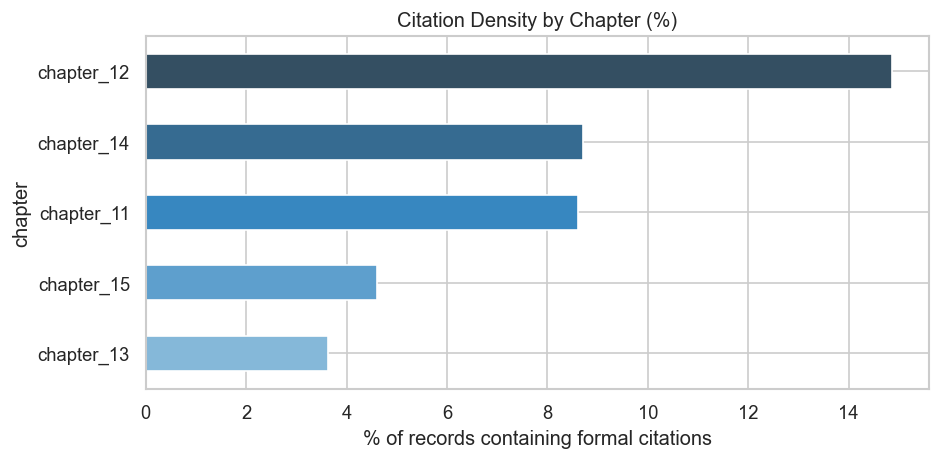

In [21]:
# 3a. Citation Pattern Discovery
# Discovering common citation formats (e.g., matching digits with dashes like XX-XX-XX) instead of just finding '§'
def extract_citations(text):
    if not isinstance(text, str): return []
    # Match standard municipal code citation patterns, e.g., '141.0302' or '11-04'
    return re.findall(r'\b\d{2,3}\.\d{4}\b', text)

df["citations"] = df["text"].apply(extract_citations)
df["has_citation"] = df["citations"].apply(len) > 0
n_with_citations = df["has_citation"].sum()

print("Citation Pattern Discovery:")
print(f"Records containing formal numeric citations: {n_with_citations:,} ({n_with_citations/len(df)*100:.1f}%)")

citation_by_chapter = df.groupby("chapter")["has_citation"].mean() * 100
citation_by_chapter = citation_by_chapter.rename("citation_density_%")

print("\nCitation density by chapter (% of records):")
print(citation_by_chapter.sort_values(ascending=False).to_string())

import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 4))
citation_by_chapter.sort_values().plot(
    kind="barh", ax=ax, color=sns.color_palette("Blues_d", len(citation_by_chapter))
)
ax.set_title("Citation Density by Chapter (%)")
ax.set_xlabel("% of records containing formal citations")
plt.tight_layout()
plt.show()


Text Length Distribution (Percentiles):

count    64639.000000
mean        60.020498
std        113.224569
min          1.000000
1%           1.000000
5%           1.000000
10%          1.000000
25%          3.000000
50%         16.000000
75%         56.000000
90%        185.000000
95%        295.000000
99%        537.000000
max       1647.000000

Empirical Noise Floor (5th percentile): <= 1 chars
Records at or below noise floor: 7,098 (11.0%)


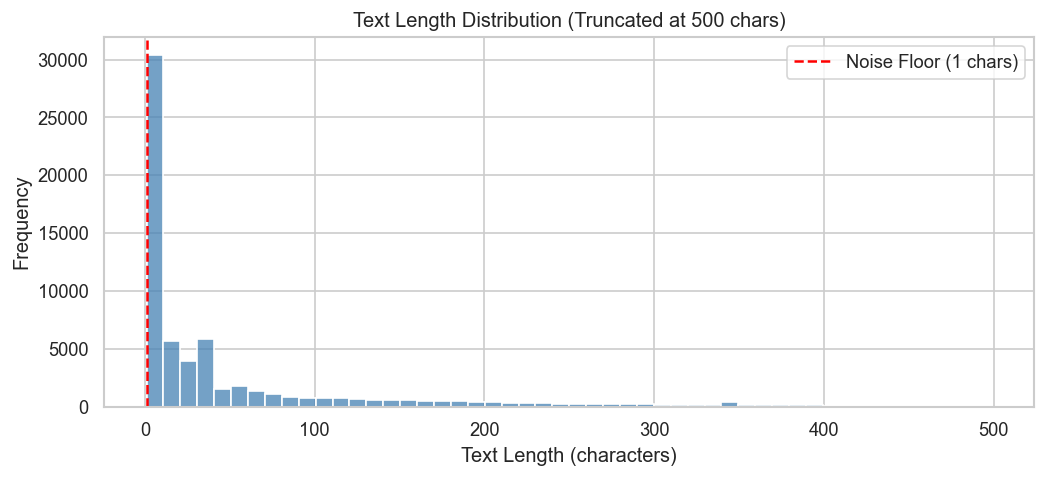

In [22]:
# 3b. Text Length Percentiles
text_len = df["text_length"]

print("Text Length Distribution (Percentiles):\n")
percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
print(text_len.describe(percentiles=percentiles).to_string())

# Determine noise floor empirically (e.g., bottom 5% of records)
noise_floor = text_len.quantile(0.05)
records_below_floor = (text_len <= noise_floor).sum()
print(f"\nEmpirical Noise Floor (5th percentile): <= {int(noise_floor)} chars")
print(f"Records at or below noise floor: {records_below_floor:,} ({(records_below_floor/len(df))*100:.1f}%)")

import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(text_len[text_len < 500], bins=50, ax=ax, color="steelblue")
ax.axvline(noise_floor, color="red", linestyle="--", label=f"Noise Floor ({int(noise_floor)} chars)")
ax.set_title("Text Length Distribution (Truncated at 500 chars)")
ax.set_xlabel("Text Length (characters)")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()


Top 20 Domain-Specific Keywords (by TF-IDF score):

             Cumulative TF-IDF Score
shall                    3083.765912
development              1798.732055
section                  1553.963910
use                      1267.739001
area                     1196.003844
effective                1102.674689
building                 1021.283302
feet                     1002.894424
10                        937.320024
public                    908.883850
regulations               903.466849
permit                    895.873625
city                      864.747815
required                  859.583996
12                        827.836319
code                      731.389182
added                     711.054379
coastal                   604.698008
amended                   572.622114
california                543.591344


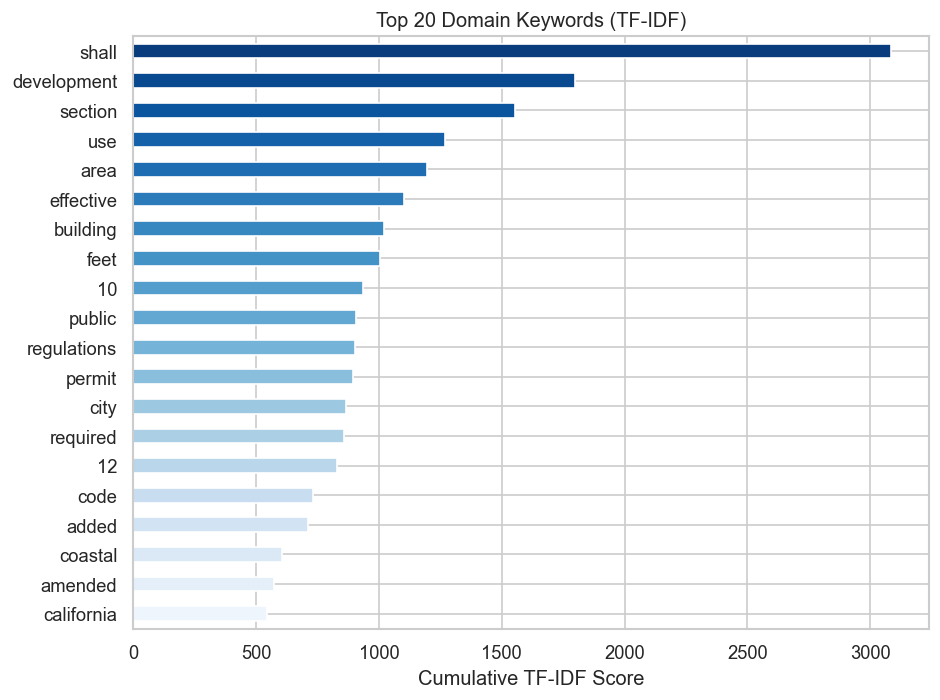

In [23]:
# 3c. Lexical Coverage (TF-IDF Top Keywords)
from sklearn.feature_extraction.text import TfidfVectorizer

# Keep only valid text to extract meaningful domain terms
valid_text = df[df["element_type"].isin(["NarrativeText", "ListItem", "Text"])]["text"].dropna()

# Compute TF-IDF to find the top 20 most significant terms across the corpus
# We exclude standard English stop words.
vectorizer = TfidfVectorizer(stop_words="english", max_features=20)
tfidf_matrix = vectorizer.fit_transform(valid_text)

# Sum the TF-IDF scores for each feature to find overall importance
tfidf_sum = tfidf_matrix.sum(axis=0).A1
keywords = vectorizer.get_feature_names_out()

# Create a sorted series
kw_series = pd.Series(tfidf_sum, index=keywords).sort_values(ascending=False)

print("Top 20 Domain-Specific Keywords (by TF-IDF score):\n")
print(kw_series.to_frame(name="Cumulative TF-IDF Score").to_string())

fig, ax = plt.subplots(figsize=(8, 6))
kw_series.plot(kind="barh", ax=ax, color=sns.color_palette("Blues_r", len(kw_series)))
ax.set_title("Top 20 Domain Keywords (TF-IDF)")
ax.set_xlabel("Cumulative TF-IDF Score")
ax.invert_yaxis() # Highest scores on top
plt.tight_layout()
plt.show()

## 4. Variable Relationships
Analysis of variable interactions to inform chunking strategy and context window management.

Cross-Reference Density by Chapter:
            total_refs  avg_refs_per_record
chapter                                    
chapter_14         606                0.029
chapter_12         430                0.072
chapter_15         252                0.019
chapter_13         179                0.008
chapter_11          71                0.028


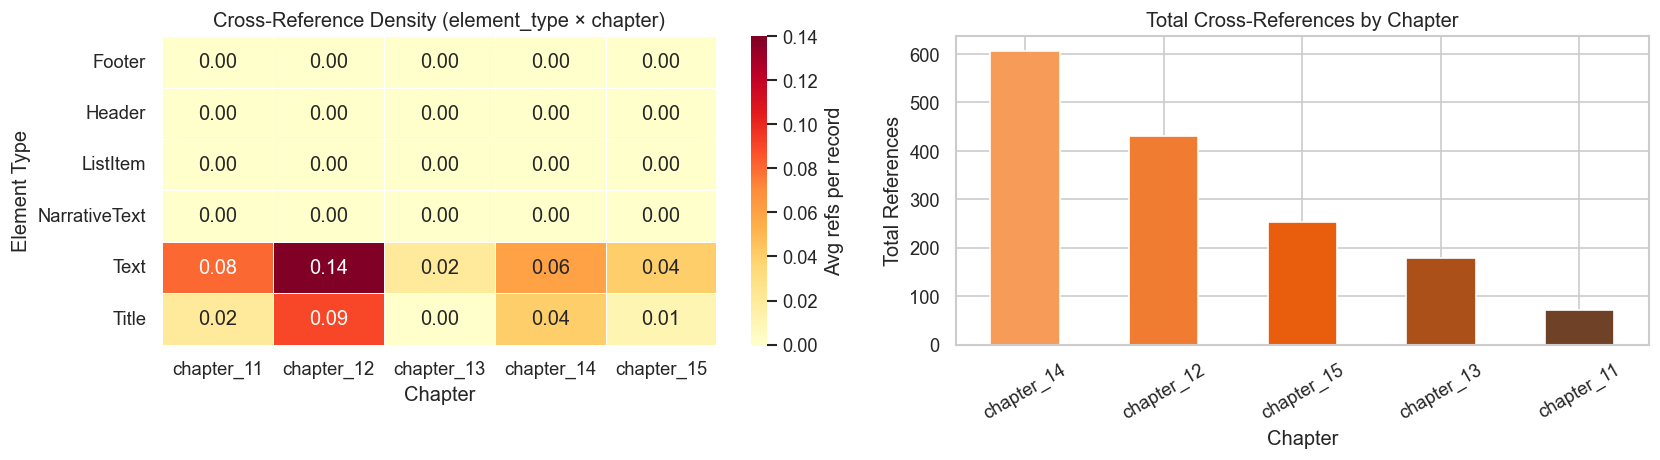

In [24]:
# 4a. Cross-Reference Density
SECTION_REF_PATTERN = r"\u00a7\d+[\d\.]*"

def count_refs(text):
    return len(re.findall(SECTION_REF_PATTERN, str(text)))

df["n_cross_refs"] = df["text"].apply(count_refs)

xref_by_chapter = df.groupby("chapter")["n_cross_refs"].agg(["sum", "mean"]).rename(
    columns={"sum": "total_refs", "mean": "avg_refs_per_record"}
).sort_values("total_refs", ascending=False)

print("Cross-Reference Density by Chapter:")
print(xref_by_chapter.round(3).to_string())

pivot = df.pivot_table(
    values="n_cross_refs", index="element_type", columns="chapter", aggfunc="mean"
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(
    pivot.round(2), annot=True, fmt=".2f", cmap="YlOrRd",
    linewidths=0.5, ax=axes[0], cbar_kws={"label": "Avg refs per record"}
)
axes[0].set_title("Cross-Reference Density (element_type \u00d7 chapter)")
axes[0].set_ylabel("Element Type")
axes[0].set_xlabel("Chapter")

xref_by_chapter["total_refs"].plot(
    kind="bar", ax=axes[1],
    color=sns.color_palette("Oranges_d", len(xref_by_chapter))
)
axes[1].set_title("Total Cross-References by Chapter")
axes[1].set_xlabel("Chapter")
axes[1].set_ylabel("Total References")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Mean Text Length by Element Type:
               mean  median   max
element_type                     
NarrativeText   206     162  1647
Header           31      33    39
Title            20      17   124
Text             18       3  1616
ListItem         14       3   457
Footer            4       2    24

Chunking Strategy Implications:
- NarrativeText: Recursive character splitting.
- Text: Append to adjacent NarrativeText.
- Title: Inject as context prefix.
- ListItem: Group consecutive ListItems.
- Header/Footer: Drop.


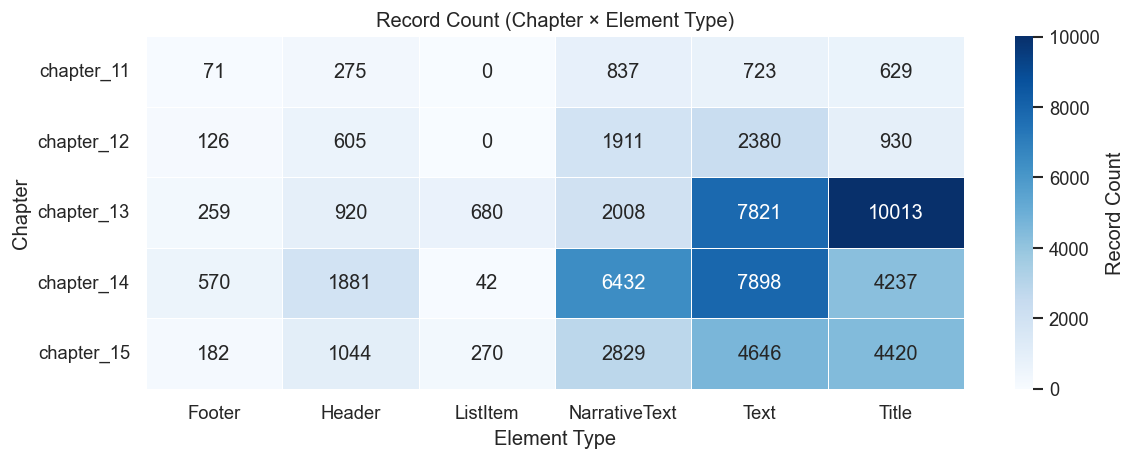

In [25]:
# 4b. Element Type vs. Text Length
print("Mean Text Length by Element Type:")
len_by_type = df.groupby("element_type")["text_length"].agg(
    ["mean", "median", "max"]
).sort_values("mean", ascending=False)
print(len_by_type.round(0).astype(int).to_string())

print("\nChunking Strategy Implications:")
print("- NarrativeText: Recursive character splitting.")
print("- Text: Append to adjacent NarrativeText.")
print("- Title: Inject as context prefix.")
print("- ListItem: Group consecutive ListItems.")
print("- Header/Footer: Drop.")

pivot2 = df.pivot_table(
    values="text_length", index="chapter", columns="element_type", aggfunc="count"
).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot2, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Record Count"}
)
ax.set_title("Record Count (Chapter \u00d7 Element Type)")
ax.set_ylabel("Chapter")
ax.set_xlabel("Element Type")
plt.tight_layout()
plt.show()

## 5. Findings Summary

- **Data Quality & Hygiene**: Noise consists of Headers and Footers. Structural debris and
  tabular fragments (high whitespace ratio) were successfully identified. Exact duplicates
  consist mostly of boilerplate components.
- **Utility for Goal**: Formal numeric citations are present across all chapters, with
  density ranging from ~3.6% (Chapter 13) to ~14.9% (Chapter 12). Text length is highly
  right-skewed (median: 16 characters). Domain-specific legal keywords show verifiable
  coverage using TF-IDF.
- **Chunking Strategy Recommendations**:
  - `Header`/`Footer` records, as well as text falling below the empirical noise floor,
    should be excluded.
  - Records identified as structural debris should be excluded or flagged.
  - Exact duplicates require deduplication.
  - The majority of clean records are short and will not require splitting. `NarrativeText`
    records exceeding the embedding token limit should be split recursively, with `Title`
    records prepended as context prefixes.